In [2]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import KNNImputer

In [4]:
df = pd.read_csv('hour.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011/1/1,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011/1/1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011/1/1,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011/1/1,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011/1/1,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011/1/1,1,0,1,5,0,6,0,2,NaN,0.2576,0.75,0.0896,0,1,1
6,7,2011/1/1,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011/1/1,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011/1/1,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011/1/1,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [5]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,16854.000000,17379.000000,16500.000000,16005.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496328,0.475775,0.627194,0.190368,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192596,0.171850,0.193217,0.122485,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.477500,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [6]:
print('Missing values in each columns: ')
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})
print(missing_table)

Missing values in each columns: 
            missing_count  missing_percent
instant                 0             0.00
dteday                  0             0.00
season                  0             0.00
yr                      0             0.00
mnth                    0             0.00
hr                      0             0.00
holiday                 0             0.00
weekday                 0             0.00
workingday              0             0.00
weathersit              0             0.00
temp                  525             3.02
atemp                   0             0.00
hum                   879             5.06
windspeed            1374             7.91
casual                  0             0.00
registered              0             0.00
cnt                     0             0.00


In [7]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

imputer = KNNImputer(n_neighbors=5)  

df_numeric = df[numeric_cols]

df_imputed = imputer.fit_transform(df_numeric)

df[numeric_cols] = pd.DataFrame(df_imputed, columns=numeric_cols)

print(df.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [8]:
target = 'cnt'
features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 
            'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
X = df[features]
y = df[target]

X = pd.get_dummies(X, columns=['season','mnth','hr','weekday','weathersit'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Import the Gradient Boosting Regressor model from sklearn
from sklearn.ensemble import GradientBoostingRegressor

# Build GBM model
gbm_model = GradientBoostingRegressor(
    n_estimators=300,     # Number of boosting stages (trees) to build
    learning_rate=0.05,   # Step size that controls how much each tree corrects previous errors
    max_depth=4,          # Maximum depth of each individual regression tree
    random_state=42       # Random seed for reproducibility
)

# Training model
gbm_model.fit(X_train, y_train)   # Train the GBM model using training features and target values

# Prediction
y_pred_gbm = gbm_model.predict(X_test)   # Predict target values on the test dataset

# Evaluation
gbm_mse = mean_squared_error(y_test, y_pred_gbm)   # Calculate Mean Squared Error (MSE)
gbm_r2 = r2_score(y_test, y_pred_gbm)   # Calculate R-squared score (model accuracy)

print("GBM MSE:", gbm_mse)   # Print MSE result
print("GBM R2:", gbm_r2)     # Print R-squared result

GBM MSE: 3680.82307358724
GBM R2: 0.8837588738552254


In [ ]:
# Feature Importance (Model Weights)
import pandas as pd               # Import pandas for DataFrame operations
import numpy as np                # Import numpy for numerical processing
import matplotlib.pyplot as plt   # Import matplotlib for plotting

# Get feature names from X_train
feature_names = X_train.columns   # Extract the column names used as model inputs

# Extract feature importance values from the GBM model
gbm_importance = gbm_model.feature_importances_   # Get the importance score for each feature

# Create a DataFrame for better display
gbm_importance_df = pd.DataFrame({
    'Feature': feature_names,                      # Feature names
    'Importance': gbm_importance                   # Corresponding importance scores
}).sort_values(by='Importance', ascending=False)   # Sort features by importance (highest first)

print(gbm_importance_df)    # Print the feature importance table

         Feature  Importance
2     workingday    0.130659
4          atemp    0.111500
37         hr_17    0.096457
0             yr    0.090553
5            hum    0.090301
3           temp    0.087164
38         hr_18    0.077197
28          hr_8    0.066163
24          hr_4    0.028146
22          hr_2    0.026377
23          hr_3    0.024719
21          hr_1    0.024175
39         hr_19    0.023616
25          hr_5    0.021440
36         hr_16    0.015781
9       season_4    0.012051
27          hr_7    0.010083
43         hr_23    0.007866
51  weathersit_3    0.007632
29          hr_9    0.005715
26          hr_6    0.004994
33         hr_13    0.004806
32         hr_12    0.004256
40         hr_20    0.003489
34         hr_14    0.003360
35         hr_15    0.003132
48     weekday_5    0.002328
31         hr_11    0.002111
6      windspeed    0.001736
49     weekday_6    0.001617
17        mnth_9    0.001597
18       mnth_10    0.001425
7       season_2    0.001295
42         hr_

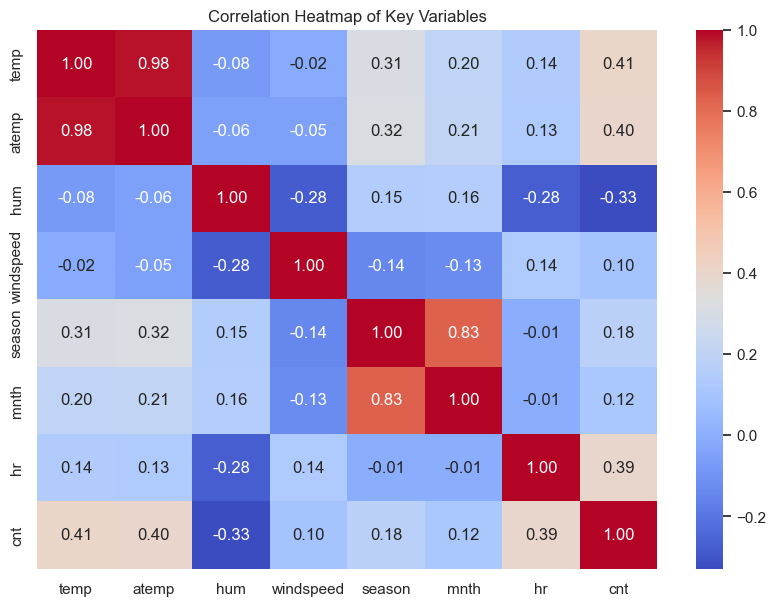

In [ ]:
# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set(style="whitegrid")

# Correlation Heatmap for Selected Features
plt.figure(figsize=(10, 7))   # Set figure size
corr = df[['temp', 'atemp', 'hum', 'windspeed', 'season', 'mnth', 'hr', 'cnt']].corr()   # Compute correlation matrix
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")   # Draw heatmap with values
plt.title("Correlation Heatmap of Key Variables")   # Add title
plt.show()   # Show plot

In [ ]:
# Import the XGBoost regressor model
from xgboost import XGBRegressor

# Build XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,    # Number of boosting trees to build
    learning_rate=0.05,  # Step size shrinkage to prevent overfitting
    max_depth=5,         # Maximum depth of each tree (controls model complexity)
    subsample=0.8,       # Fraction of training samples used per tree (reduces overfitting)
    colsample_bytree=0.8,   # Fraction of features used per tree (feature subsampling)
    random_state=42,     # Random seed for reproducibility
    objective='reg:squarederror'  # Loss function for regression
)

# Training model
xgb_model.fit(X_train, y_train)   # Train the XGBoost model using the training dataset

# Prediction
y_pred_xgb = xgb_model.predict(X_test)   # Predict target values for the test dataset

# Evaluation
xgb_mse = mean_squared_error(y_test, y_pred_xgb)   # Compute Mean Squared Error (MSE)
xgb_r2 = r2_score(y_test, y_pred_xgb)   # Compute R-squared score

print("XGBoost MSE:", xgb_mse)   # Display the MSE result
print("XGBoost R2:", xgb_r2)   # Display the R-squared result

XGBoost MSE: 2463.8953372323695
XGBoost R2: 0.9221896942675852


In [ ]:
# Feature Importance (Model Weights) for XGBoost
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names from X_train
feature_names = X_train.columns

# Extract feature importance scores from the XGBoost model
xgb_importance = xgb_model.feature_importances_

# Create a DataFrame to display importance values
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,   # Feature names
    'Importance': xgb_importance   # Importance scores
}).sort_values(by='Importance', ascending=False)   # Sort by importance

print(xgb_importance_df)     # Print importance table

         Feature  Importance
37         hr_17    0.104367
24          hr_4    0.088052
23          hr_3    0.082997
38         hr_18    0.077767
25          hr_5    0.077510
22          hr_2    0.076925
21          hr_1    0.072596
28          hr_8    0.065840
43         hr_23    0.037017
39         hr_19    0.032570
36         hr_16    0.025317
2     workingday    0.023040
26          hr_6    0.022578
0             yr    0.020049
4          atemp    0.018988
27          hr_7    0.018704
9       season_4    0.011627
3           temp    0.011119
29          hr_9    0.010990
5            hum    0.010270
32         hr_12    0.009096
33         hr_13    0.008614
40         hr_20    0.008035
31         hr_11    0.007634
51  weathersit_3    0.007257
34         hr_14    0.006489
42         hr_22    0.006357
35         hr_15    0.005905
17        mnth_9    0.005277
30         hr_10    0.004563
49     weekday_6    0.004444
18       mnth_10    0.003450
41         hr_21    0.002544
15        mnth

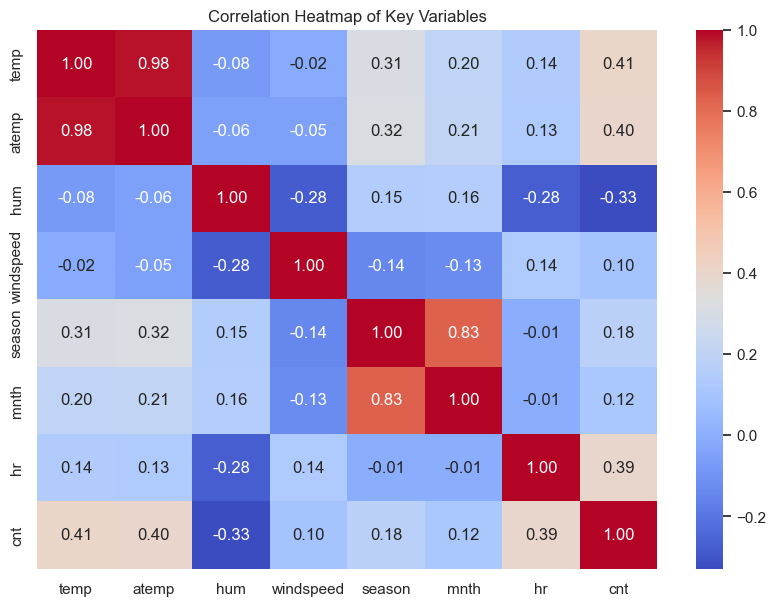

In [ ]:
# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")   # Set visualization style

# Correlation Heatmap for selected numeric features
plt.figure(figsize=(10, 7))   # Set figure size
corr = df[['temp', 'atemp', 'hum', 'windspeed', 'season', 'mnth', 'hr', 'cnt']].corr()   # Compute correlation matrix
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt='.2f')   # Draw heatmap
plt.title("Correlation Heatmap of Key Variables")    # Add title
plt.show()   # Display plot